In [28]:
#Quy trình chi tiết dự đoán giá cổ phiếu bằng Python:
#1. Thu thập dữ liệu (Data Acquisition): Sử dụng thư việnđể tải dữ liệu giá chứng khoán (Open, High, Low, Close, Volume).
#2. Xử lý và phân tích dữ liệu (Preprocessing & EDA): Dùng pandas để làm sạch dữ liệu, xử lý giá trị khuyết và tính toán các chỉ báo kỹ thuật như MA (Moving Average) hoặc RSI
#3. Lựa chọn mô hình:Machine Learning truyền thống: Hồi quy tuyến tính (Linear Regression), SVM, hoặc Random Forest (dùng scikit-learn) cho các dự đoán cơ bản.
#4. Huấn luyện và Đánh giá (Training & Evaluation): Chia dữ liệu thành tập huấn luyện (train) và kiểm thử (test), sau đó dùng metrics (như MSE, RMSE) hoặc đường cong ROC-AUC để đo lường độ chính xác.
#5. Hình ảnh hóa (Visualization): Sử dụng matplotlib hoặc plotly để vẽ biểu đồ nến, đường xu hướng so sánh giá dự đoán và giá thực tế.

In [29]:
#1 Thu thập dữ liệu

In [30]:
pip install vnstock

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from vnstock import Vnstock

stock = Vnstock().stock(symbol='VNM', source='KBS')

df = stock.quote.history(
    start='2020-01-01',
    end='2026-04-29',
    interval='1D'
)

print(df.head())


  ╭──────────────────────────────────────────────────────────╮
  │  ⚠️  VNSTOCK DEPRECATION NOTICE (31/08/2025)             │
  │                                                          │
  │  Lớp Vnstock và các phương thức cũ (stock, fx, crypto,   │
  │  world_index, fund...) đã chính thức bị ngừng hỗ trợ.    │
  │                                                          │
  │  Để hệ thống ổn định và nhận được cập nhật mới nhất,     │
  │  vui lòng chuyển sang dùng bộ thư viện `vnstock.api`.    │
  │                                                          │
  │  👉 Xem hướng dẫn Migration: /vnstock-migration          │
  ╰──────────────────────────────────────────────────────────╯

Mẫu code chuyển đổi (Migration Example):
--------------------------------------
Cũ (Old):  stock = Vnstock().stock('ACB')
Mới (New): from vnstock.api.quote import Quote
          q = Quote(symbol='ACB', source='VCI')

                 time   open   high    low  close  volume
0 2020-01-02 07:00:00  71.66  

In [32]:
#2 Xử lý và phân tích dữ liệu (Preprocessing & EDA

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1576 non-null   datetime64[ns]
 1   open    1576 non-null   float64       
 2   high    1576 non-null   float64       
 3   low     1576 non-null   float64       
 4   close   1576 non-null   float64       
 5   volume  1576 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 74.0 KB


In [34]:
# a)Check missing
df.isnull().sum()

time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [35]:
# b)Tính toán các chỉ báo kỹ thuật

In [36]:
# EMA 50 VÀ EMA 200
df["EMA50"] = df["close"].ewm(span=50, adjust=False).mean()
df["EMA200"] = df["close"].ewm(span=200, adjust=False).mean()

In [37]:
#Bollinger Bands
df["MA20"] = df["close"].rolling(window=20).mean()
df["STD20"] = df["close"].rolling(window=20).std()

df["Upper_BB"] = df["MA20"] + 2 * df["STD20"]
df["Lower_BB"] = df["MA20"] - 2 * df["STD20"]

In [38]:
#RSI
delta = df["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Wilder smoothing (giống ta.rma)
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))

In [39]:
# 3 Lựa chọn mô hình (Linear Regression)

In [40]:
df["target"] = df["close"].shift(-1)

In [41]:
df = df.dropna()

In [42]:
# 4 Huấn luyện và đanh giá

In [43]:
# Tách dữ liệu để train và test

In [44]:
features = [ "EMA50","EMA200","Upper_BB","Lower_BB","RSI"]
X = df[features]
y = df["target"]

In [45]:
#Split dữ liệu để train và test
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [46]:
#Train model
!pip install scikit-learn
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
#Đánh giá model

In [48]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2.463063983644799
RMSE: 1.5694151724909502


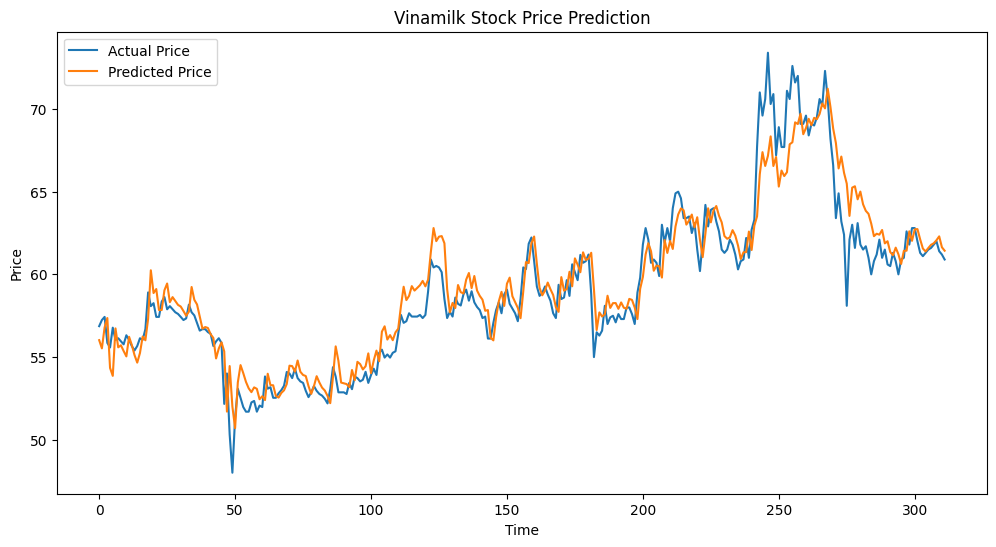

In [49]:
#5 Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.legend()
plt.title("Vinamilk Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

In [50]:
latest = df.iloc[-1]

In [51]:
features = ["EMA50", "EMA200", "Upper_BB", "Lower_BB", "RSI"]

X_latest = latest[features].values.reshape(1, -1)

In [52]:
predicted_price = model.predict(X_latest)

print("Giá dự đoán ngày mai:", predicted_price[0])

Giá dự đoán ngày mai: 61.43176549116177


X does not have valid feature names, but LinearRegression was fitted with feature names
